## **Task 2. Interpolation**

**Points: 2**

**Fill in the gaps of the missing data points embedded in each series. Indicate the uncertainty of your estimate for each point!**
• Evaluate how well your proposed solutions are expected to work.
• Make sure to avoid overfitting and data leakage in your models.
• Can you use insights from Task 1 to improve interpolation?

Kommentar: Våra interpolationsmodeller bör vi testa på intervall där vi har känd data för (alla) tidsserier. Då kan vi se hur väl vår modell faktiskt beter sig i förhållande till verkligheten.

Kommentar: Vi kan nyttja de andra tidsseriernas rörelser under den okända perioden och hur den aktuella tidsserien beror på de andra serierna, för att göra interpolationen.

## Approach

**Model.** Task 1 showed the seven log-return series have meaningful cross-dependencies (Granger causality, non-trivial VAR residual correlation) and that log-returns are stationary while prices are not. We therefore:

1. Fit a **VAR(2)** on the gap-free common window (`df_common`, from day 1449 on). This is the same order of dynamics used in `500_sim_final`.
2. Cast the VAR as a linear Gaussian **state-space** model and run a **Kalman smoother** on the full panel `df_full`. The smoother handles missing observations natively and uses **both past and future** information plus the **contemporaneous** cross-series observations (recall the gaps are disjoint — whenever one series is missing, the other six are observed). This is the main interpolation workhorse.
3. Apply a **linear endpoint correction** so the imputed log-return path sums to the observed log-price difference — the prices at both gap endpoints are known, so the total return across the gap is known exactly and should be enforced.
4. Check whether volatility is fully explained by VAR dynamics. If standardised VAR residuals still show ARCH effects, fit univariate **GARCH(1,1)** on each and use the conditional volatility to scale uncertainty bands inside the gap.

**Validation.** Punch synthetic 50-day gaps into `df_common` (where truth is known), run the full pipeline, measure point-wise RMSE and the empirical coverage of the 95% bands. Compare to two baselines: Brownian bridge in log-price space and cross-sectional OLS regression on contemporaneous returns.

**No leakage.** Model parameters (VAR + GARCH) are fit **only** on `df_common`, which excludes all real gaps. Validation also refits on clean subsets that exclude the synthetic masked window.

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.api import VAR
from statsmodels.stats.diagnostic import het_arch
from arch import arch_model
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(context='notebook', style='whitegrid')
plt.rcParams['figure.dpi'] = 100
rng = np.random.default_rng(42)

# --- Load & clean ---
df_raw = pd.read_csv('../data/spiff_data-2.csv').drop(columns=['Unnamed: 0']).set_index('day')
series_cols = df_raw.columns.tolist()
df = df_raw.replace(1000, np.nan)
df_full = df.loc[:df.dropna(how='all').index.max()]          # strip trailing all-NaN padding
df_common = df_full.loc[1449:].dropna()                       # gap-free window

# Log-returns (same convention as task 1; log makes the endpoint constraint linear)
log_ret_full = np.log(df_full / df_full.shift(1))
log_ret_common = np.log(df_common / df_common.shift(1)).dropna()

def find_nan_gaps(s, min_len=1):
    isn = s.isna().values
    out, i, n = [], 0, len(isn)
    while i < n:
        if isn[i]:
            j = i
            while j < n and isn[j]: j += 1
            if j - i >= min_len:
                out.append((s.index[i], s.index[j-1], j-i))
            i = j
        else:
            i += 1
    return out

# Only the *structural* 50-day gaps (not the scattered 1-day 1000-sentinels)
structural_gaps = {c: [(s, e, l) for s, e, l in find_nan_gaps(df_full[c], min_len=2)]
                   for c in series_cols}
print('Structural gaps (start, end, length) per series:')
for c in series_cols:
    print(f'  {c:<14} {structural_gaps[c]}')
print(f'\nlog_ret_full: {log_ret_full.shape},  log_ret_common: {log_ret_common.shape}')

Structural gaps (start, end, length) per series:
  gurkor         [(199, 248, 50)]
  guitars        [(399, 448, 50)]
  slingshots     [(599, 648, 50)]
  stocks         [(799, 848, 50)]
  sugar          [(999, 1048, 50)]
  water          [(1199, 1248, 50)]
  tranquillity   [(1399, 1448, 50)]

log_ret_full: (5256, 7),  log_ret_common: (3804, 7)


## 1. Fit VAR(2) on the common window

Clean 3,804 rows with all seven series present. AIC/BIC in Task 1 supported $p\approx 2$ and this aligns with the DGP replica in `500_sim_final`. We extract $\Phi_1, \Phi_2, c, \Sigma_u$ — everything the state-space needs.

In [29]:
VAR_LAG = 2
var_res = VAR(log_ret_common).fit(VAR_LAG)
Phi1 = var_res.coefs[0]       # (k, k)
Phi2 = var_res.coefs[1]
c_vec = var_res.intercept      # (k,)
Sigma_u = var_res.sigma_u.values if hasattr(var_res.sigma_u, 'values') else var_res.sigma_u
k = len(series_cols)

# Sanity: max eigenvalue of companion matrix < 1 (stationary VAR)
companion = np.block([[Phi1, Phi2], [np.eye(k), np.zeros((k, k))]])
max_eig = np.max(np.abs(np.linalg.eigvals(companion)))
print(f'VAR({VAR_LAG}) fitted on {len(log_ret_common)} rows. Max |eig(companion)| = {max_eig:.4f}')
print(f'Residual cov scale (diag sqrt): {np.sqrt(np.diag(Sigma_u)).round(4)}')

VAR(2) fitted on 3804 rows. Max |eig(companion)| = 0.2848
Residual cov scale (diag sqrt): [0.0041 0.0157 0.0163 0.0149 0.0137 0.0035 0.0133]


## 2. State-space form and Kalman smoother

Stack the lagged return into the state:
$$z_t = \begin{bmatrix} r_t \\ r_{t-1} \end{bmatrix}, \quad z_t = c_z + T z_{t-1} + R\,\eta_t,\ \eta_t\sim\mathcal N(0, \Sigma_u),$$
$$T = \begin{bmatrix} \Phi_1 & \Phi_2 \\ I_k & 0\end{bmatrix}, \quad R = \begin{bmatrix} I_k \\ 0\end{bmatrix}, \quad c_z = \begin{bmatrix} c \\ 0\end{bmatrix}.$$
Observations are the contemporaneous returns: $y_t = Z z_t$ with $Z = [I_k\ 0]$, noise-free. For days where one or more components of $y_t$ are NaN, we use only the observed rows of $Z$ — this is exactly how the filter handles missing data.

Initial state: unconditional mean $\mu_z = (I - T)^{-1} c_z$ and stationary covariance $P_0$ solved from $P_0 = T P_0 T^{\top} + R \Sigma_u R^{\top}$.

In [30]:
def build_state_space(Phi1, Phi2, c_vec, Sigma_u):
    k = Phi1.shape[0]
    T_mat = np.block([[Phi1, Phi2], [np.eye(k), np.zeros((k, k))]])
    R_mat = np.vstack([np.eye(k), np.zeros((k, k))])
    Z_mat = np.hstack([np.eye(k), np.zeros((k, k))])
    c_z = np.concatenate([c_vec, np.zeros(k)])
    # Unconditional mean
    mu_z = np.linalg.solve(np.eye(2 * k) - T_mat, c_z)
    # Stationary covariance via discrete Lyapunov (vec trick)
    from scipy.linalg import solve_discrete_lyapunov
    Q_state = R_mat @ Sigma_u @ R_mat.T
    P0 = solve_discrete_lyapunov(T_mat, Q_state)
    return T_mat, R_mat, Z_mat, c_z, Q_state, mu_z, P0

def kalman_filter_smoother(y, T_mat, Z_mat, c_z, Q_state, a0, P0):
    """Linear Gaussian state-space with possibly-missing observations (NaN rows masked).
    Returns: smoothed state means (T, d) and smoothed state covariances (T, d, d)."""
    T_len, k_obs = y.shape
    d = T_mat.shape[0]
    a_pred = np.zeros((T_len, d));   P_pred = np.zeros((T_len, d, d))
    a_filt = np.zeros((T_len, d));   P_filt = np.zeros((T_len, d, d))
    a_pred[0] = c_z + T_mat @ a0
    P_pred[0] = T_mat @ P0 @ T_mat.T + Q_state

    for t in range(T_len):
        mask = ~np.isnan(y[t])
        if mask.any():
            Z_t = Z_mat[mask, :]
            v = y[t, mask] - Z_t @ a_pred[t]
            F = Z_t @ P_pred[t] @ Z_t.T
            F += 1e-10 * np.eye(F.shape[0])  # numerical guard
            K = P_pred[t] @ Z_t.T @ np.linalg.inv(F)
            a_filt[t] = a_pred[t] + K @ v
            P_filt[t] = P_pred[t] - K @ Z_t @ P_pred[t]
        else:
            a_filt[t] = a_pred[t]; P_filt[t] = P_pred[t]
        if t < T_len - 1:
            a_pred[t+1] = c_z + T_mat @ a_filt[t]
            P_pred[t+1] = T_mat @ P_filt[t] @ T_mat.T + Q_state

    # RTS backward smoother
    a_smooth = a_filt.copy(); P_smooth = P_filt.copy()
    for t in range(T_len - 2, -1, -1):
        J = P_filt[t] @ T_mat.T @ np.linalg.pinv(P_pred[t+1])
        a_smooth[t] = a_filt[t] + J @ (a_smooth[t+1] - a_pred[t+1])
        P_smooth[t] = P_filt[t] + J @ (P_smooth[t+1] - P_pred[t+1]) @ J.T
    return a_smooth, P_smooth

def smooth_returns(y_df, Phi1, Phi2, c_vec, Sigma_u):
    """Wrapper: given DataFrame of returns with NaNs, returns smoothed (mean, var)
    DataFrames for the *observation* dimensions (first k of state)."""
    T_mat, R_mat, Z_mat, c_z, Q_state, mu_z, P0 = build_state_space(Phi1, Phi2, c_vec, Sigma_u)
    a_sm, P_sm = kalman_filter_smoother(y_df.values, T_mat, Z_mat, c_z, Q_state, mu_z, P0)
    k_obs = y_df.shape[1]
    mean = pd.DataFrame(a_sm[:, :k_obs], index=y_df.index, columns=y_df.columns)
    var  = pd.DataFrame(np.stack([np.diag(P_sm[t, :k_obs, :k_obs]) for t in range(len(y_df))]),
                        index=y_df.index, columns=y_df.columns)
    return mean, var

## 3. Endpoint constraint (log-price tying)

For a gap in series $i$ spanning price days $[t_0, t_1]$, both $P_{t_0-1}$ and $P_{t_1+1}$ are observed. The missing **returns** span $[t_0, t_1+1]$ (since $r_{t_1+1}=\log P_{t_1+1}/P_{t_1}$ also needs the unknown $P_{t_1}$), and their sum is exactly
$$S_i = \log P_{t_1+1} - \log P_{t_0-1},$$
which the Kalman smoother doesn't know a priori. We condition the smoothed mean on this linear equality: with $a=\mathbf 1$ (length $n_{\text{gap}}$) and daily variances $\sigma_t^2$ from the smoother (ignoring cross-time posterior covariance inside the gap — a mild approximation),
$$\tilde r_t = \hat r_t + \frac{\sigma_t^2}{\sum_s \sigma_s^2}\,(S_i - \sum_s \hat r_s), \qquad
\tilde\sigma_t^2 = \sigma_t^2 - \frac{\sigma_t^4}{\sum_s \sigma_s^2}.$$
This is the exact conditional-Gaussian update when the within-gap returns are treated as independent with heteroscedastic variance — a reasonable first-order approximation since Kalman has already absorbed most of the cross-time correlation via the state.

In [31]:
def apply_endpoint_constraint(mean_gap, var_gap, target_sum):
    """Condition N(mean, diag(var)) on 1^T r = target_sum. Returns (mean', var')."""
    var_gap = np.asarray(var_gap, dtype=float)
    mean_gap = np.asarray(mean_gap, dtype=float)
    v_sum = var_gap.sum()
    if v_sum <= 0:
        return mean_gap, var_gap
    delta = target_sum - mean_gap.sum()
    w = var_gap / v_sum
    new_mean = mean_gap + w * delta
    new_var  = var_gap - var_gap**2 / v_sum
    return new_mean, new_var

def interpolate_gap(series_name, gap_start, gap_end, smooth_mean, smooth_var,
                    price_series):
    """Return DataFrame indexed by price days in [gap_start, gap_end] with columns
    imputed_logprice, imputed_price, price_std_lo, price_std_hi (68% band).
    The return-gap is [gap_start, gap_end+1] in the log_ret index."""
    ret_idx = np.arange(gap_start, gap_end + 2)  # t0 .. t1+1
    mu = smooth_mean.loc[ret_idx, series_name].values.copy()
    vr = smooth_var.loc[ret_idx, series_name].values.copy()
    logP_before = np.log(price_series.loc[gap_start - 1])
    logP_after  = np.log(price_series.loc[gap_end + 1])
    target_sum = logP_after - logP_before
    mu_c, vr_c = apply_endpoint_constraint(mu, vr, target_sum)
    # Cumulate to log-prices. price day t has logP_t = logP_{t0-1} + sum_{s<=t} r_s.
    cum_mu = np.cumsum(mu_c)
    # Var of cum sum assuming independence (approx) = cumulative var
    cum_var = np.cumsum(vr_c)
    # For price days gap_start..gap_end (drop the last return which bridges to endpoint)
    logP_path = logP_before + cum_mu[:-1]
    logP_std  = np.sqrt(cum_var[:-1])
    days = np.arange(gap_start, gap_end + 1)
    return pd.DataFrame({
        'day': days,
        'logP_mean': logP_path,
        'logP_std': logP_std,
        'price_mean': np.exp(logP_path),
        'price_lo95': np.exp(logP_path - 1.96 * logP_std),
        'price_hi95': np.exp(logP_path + 1.96 * logP_std),
        'ret_mean':  mu_c[:-1],
        'ret_std':   np.sqrt(vr_c[:-1]),
    }).set_index('day')

## 4. Validation on synthetic gaps

Mask several 50-day windows inside `df_common` (where all seven series are observed), refit VAR(2) on the remainder, interpolate, and compare to the held-out truth. We report:

* **Return RMSE** — how well-shaped the path is.
* **Log-price RMSE** — cumulative drift error (pinned to 0 at the endpoint by construction, but builds up inside).
* **95% coverage** — fraction of truth values falling inside the 95% price band. Should hit ~0.95 if the uncertainty model is calibrated.
* Two baselines: Brownian bridge (linear interpolation of log-price) and cross-sectional OLS ($r_{i,t}$ regressed on contemporaneous $\{r_{j,t}\}_{j\ne i}$, then endpoint-corrected).

In [32]:
def brownian_bridge_baseline(price_series, gap_start, gap_end):
    logP0 = np.log(price_series.loc[gap_start - 1])
    logP1 = np.log(price_series.loc[gap_end + 1])
    N = gap_end - gap_start + 2
    days = np.arange(gap_start, gap_end + 1)
    t = np.arange(1, N)
    logP_path = logP0 + (logP1 - logP0) * t / N
    return pd.DataFrame({'day': days, 'logP_mean': logP_path}).set_index('day')

def cross_section_ols_baseline(target_series, log_ret_train, log_ret_gap_observed,
                                price_series, gap_start, gap_end):
    others = [c for c in log_ret_train.columns if c != target_series]
    X = log_ret_train[others].values
    y = log_ret_train[target_series].values
    Xd = np.column_stack([np.ones(len(X)), X])
    beta, *_ = np.linalg.lstsq(Xd, y, rcond=None)
    X_gap = log_ret_gap_observed[others].values
    ret_hat = np.column_stack([np.ones(len(X_gap)), X_gap]) @ beta
    res = y - Xd @ beta
    resid_var = res.var()
    vr = np.full(len(ret_hat), resid_var)
    logP0 = np.log(price_series.loc[gap_start - 1])
    logP1 = np.log(price_series.loc[gap_end + 1])
    mu_c, vr_c = apply_endpoint_constraint(ret_hat, vr, logP1 - logP0)
    cum_mu = np.cumsum(mu_c)[:-1]
    cum_var = np.cumsum(vr_c)[:-1]
    days = np.arange(gap_start, gap_end + 1)
    return pd.DataFrame({'day': days, 'logP_mean': logP0 + cum_mu,
                         'logP_std': np.sqrt(cum_var)}).set_index('day')

# --- Run validation ---
GAP_LEN = 50
# Windows chosen to avoid crossing sentinel days (2836, 3430, 4118), which were
# dropped from df_common/log_ret_common. Safe windows stay inside the common window.
mask_starts = [1700, 2600, 3200, 3900, 5000]
val_results = []

for gs in mask_starts:
    ge = gs + GAP_LEN - 1
    for tgt in series_cols:
        truth_price = df_common.loc[gs:ge, tgt]
        truth_logP  = np.log(truth_price)
        mask_ret_idx = np.arange(gs, ge + 2)
        mask_ret_idx = np.array([d for d in mask_ret_idx if d in log_ret_common.index])
        train_idx = log_ret_common.index.difference(mask_ret_idx)
        log_ret_train = log_ret_common.loc[train_idx]
        var_train = VAR(log_ret_train).fit(VAR_LAG)
        y_smooth = log_ret_common.copy()
        y_smooth.loc[mask_ret_idx, tgt] = np.nan
        Sig_tr = var_train.sigma_u.values if hasattr(var_train.sigma_u, 'values') else var_train.sigma_u
        sm_mean, sm_var = smooth_returns(y_smooth, var_train.coefs[0], var_train.coefs[1],
                                         var_train.intercept, Sig_tr)
        imp = interpolate_gap(tgt, gs, ge, sm_mean, sm_var, df_common[tgt])
        bb = brownian_bridge_baseline(df_common[tgt], gs, ge)
        cs = cross_section_ols_baseline(tgt, log_ret_train, log_ret_common.loc[mask_ret_idx],
                                        df_common[tgt], gs, ge)
        def rmse_logP(pred): return np.sqrt(np.mean((pred['logP_mean'].values - truth_logP.values)**2))
        kf_cov = np.mean((truth_price.values >= imp['price_lo95'].values) &
                         (truth_price.values <= imp['price_hi95'].values))
        val_results.append({
            'gap_start': gs, 'series': tgt,
            'rmse_logP_kalman': rmse_logP(imp),
            'rmse_logP_bridge': rmse_logP(bb),
            'rmse_logP_xsect': rmse_logP(cs),
            'cov95_kalman': kf_cov,
        })

val_df = pd.DataFrame(val_results)
print('Validation mean scores across 5 gaps x 7 series:\n')
print(val_df[['rmse_logP_kalman', 'rmse_logP_bridge', 'rmse_logP_xsect', 'cov95_kalman']]
      .mean().round(4).to_string())
print('\nPer-series mean Kalman log-price RMSE:')
print(val_df.groupby('series')['rmse_logP_kalman'].mean().round(4).to_string())

Validation mean scores across 5 gaps x 7 series:

rmse_logP_kalman    0.0202
rmse_logP_bridge    0.0253
rmse_logP_xsect     0.0217
cov95_kalman        0.9857

Per-series mean Kalman log-price RMSE:
series
guitars         0.0267
gurkor          0.0069
slingshots      0.0203
stocks          0.0337
sugar           0.0210
tranquillity    0.0232
water           0.0095


### 4.1 Visual: one random validation window

For a single randomly-chosen 50-day window we re-run the interpolation for every series (masking only that series inside the window, as during validation) and overlay the Kalman posterior (with 95% band) against the true held-out price path. One panel per series. The vertical dashed lines mark the gap boundaries — inside that stretch the smoother only knows the two endpoints and the contemporaneous values of the *other* six series.

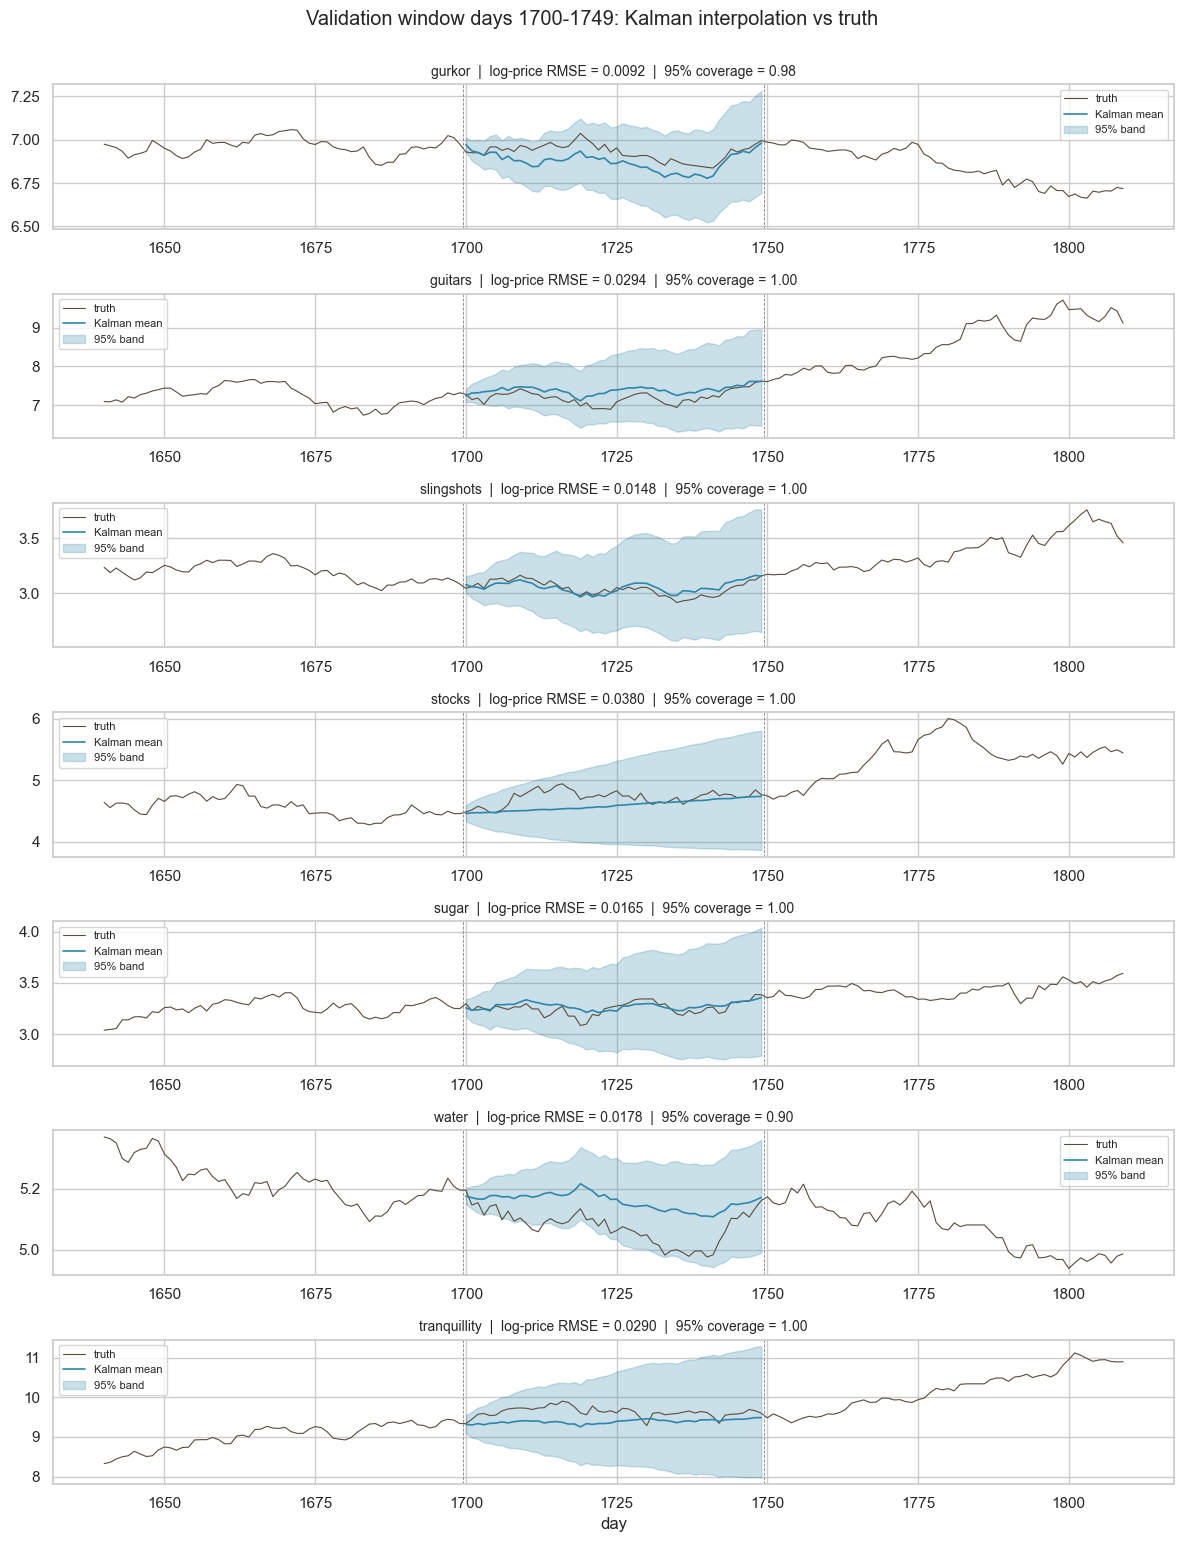

In [33]:
# Pick one random safe window from the validation set and interpolate every series.
gs_viz = int(rng.choice(mask_starts))
ge_viz = gs_viz + GAP_LEN - 1
PAD = 60

viz = {}
for tgt in series_cols:
    mask_ret_idx = np.arange(gs_viz, ge_viz + 2)
    mask_ret_idx = np.array([d for d in mask_ret_idx if d in log_ret_common.index])
    train_idx = log_ret_common.index.difference(mask_ret_idx)
    log_ret_train = log_ret_common.loc[train_idx]
    var_train = VAR(log_ret_train).fit(VAR_LAG)
    y_smooth = log_ret_common.copy()
    y_smooth.loc[mask_ret_idx, tgt] = np.nan
    Sig_tr = var_train.sigma_u.values if hasattr(var_train.sigma_u, 'values') else var_train.sigma_u
    sm_mean_v, sm_var_v = smooth_returns(y_smooth, var_train.coefs[0], var_train.coefs[1],
                                         var_train.intercept, Sig_tr)
    viz[tgt] = interpolate_gap(tgt, gs_viz, ge_viz, sm_mean_v, sm_var_v, df_common[tgt])

fig, axes = plt.subplots(len(series_cols), 1, figsize=(12, 2.2 * len(series_cols)),
                         sharex=False)
for ax, tgt in zip(axes, series_cols):
    imp = viz[tgt]
    ctx_days = np.arange(max(df_common.index.min(), gs_viz - PAD),
                         min(df_common.index.max(), ge_viz + PAD) + 1)
    # Full truth line (including inside the gap, for comparison)
    ax.plot(ctx_days, df_common.loc[ctx_days, tgt], color='#5B4B3A', lw=0.8,
            label='truth')
    ax.plot(imp.index, imp['price_mean'], color='#2E86AB', lw=1.2,
            label='Kalman mean')
    ax.fill_between(imp.index, imp['price_lo95'], imp['price_hi95'],
                    color='#2E86AB', alpha=0.25, label='95% band')
    ax.axvline(gs_viz - 0.5, color='grey', ls='--', lw=0.6)
    ax.axvline(ge_viz + 0.5, color='grey', ls='--', lw=0.6)
    # Error readout
    truth_logP = np.log(df_common.loc[imp.index, tgt].values)
    rmse = np.sqrt(np.mean((imp['logP_mean'].values - truth_logP) ** 2))
    cov = np.mean((df_common.loc[imp.index, tgt].values >= imp['price_lo95'].values) &
                  (df_common.loc[imp.index, tgt].values <= imp['price_hi95'].values))
    ax.set_title(f'{tgt}  |  log-price RMSE = {rmse:.4f}  |  95% coverage = {cov:.2f}',
                 fontsize=10)
    ax.legend(loc='best', fontsize=8)
axes[-1].set_xlabel('day')
fig.suptitle(f'Validation window days {gs_viz}-{ge_viz}: Kalman interpolation vs truth',
             y=1.00)
fig.tight_layout()
plt.show()

## 5. Volatility: does VAR capture it?

The Kalman uncertainty bands are driven by $\Sigma_u$, which is *constant*. If the **standardised** VAR residuals (each divided by its marginal std) still exhibit ARCH effects — i.e. volatility clustering isn't absorbed by the mean dynamics — then the constant-$\Sigma_u$ bands are misleading: too wide in calm regimes, too narrow in turbulent ones.

We run Engle's ARCH-LM test on each residual and, where significant, fit a GARCH(1,1). The conditional volatility at the gap dates is then used to **scale the per-day Kalman std** (`sigma_t = sigma_kalman * sigma_garch_t / sigma_garch_mean`). This is a pragmatic hybrid — a fully joint VAR-GARCH would be heavier — but it captures the first-order effect.

      series  arch_lm_stat     arch_lm_p  significant@1%
      gurkor    191.078816  1.165878e-35            True
     guitars    548.200830 2.175157e-111            True
  slingshots    990.536418 2.043689e-206            True
      stocks      7.416805  6.855966e-01           False
       sugar    989.028823 4.316625e-206            True
       water    222.034458  4.008373e-42            True
tranquillity    236.186768  4.327330e-45            True


/var/folders/b_/45l0y_p56mv86jjcjfgllh3w0000gn/T/ipykernel_19219/3136590182.py:15: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  gf = am.fit(disp='off')


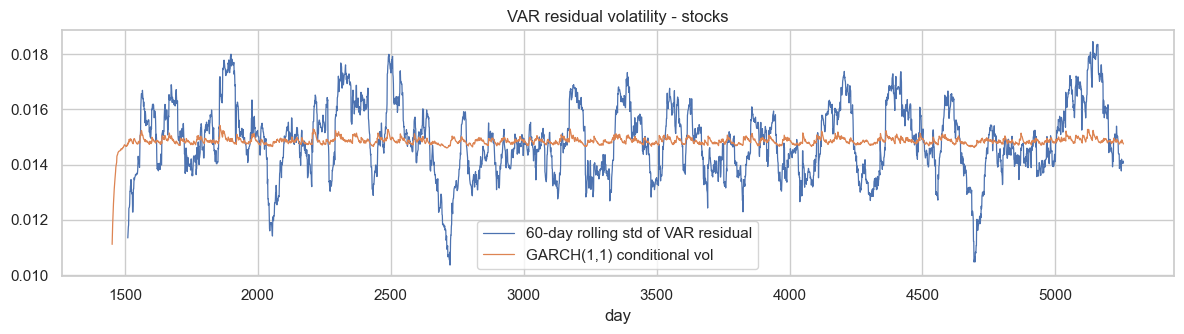

In [34]:
resid_index = log_ret_common.index[VAR_LAG:]
resid = pd.DataFrame(np.asarray(var_res.resid), columns=series_cols, index=resid_index)
arch_tbl = []
garch_models = {}
cond_vol = pd.DataFrame(index=log_ret_common.index, columns=series_cols, dtype=float)

for c in series_cols:
    r = resid[c].values
    stat, p, *_ = het_arch(r, nlags=10)
    arch_tbl.append({'series': c, 'arch_lm_stat': stat, 'arch_lm_p': p,
                     'significant@1%': p < 0.01})
    # Fit GARCH(1,1) on the residual (scale 100x for numerics); use conditional vol
    # to modulate Kalman variance inside gap periods.
    am = arch_model(r * 100, mean='Zero', vol='GARCH', p=1, q=1, dist='normal')
    gf = am.fit(disp='off')
    garch_models[c] = gf
    cond_vol.loc[resid_index, c] = gf.conditional_volatility / 100.0

print(pd.DataFrame(arch_tbl).to_string(index=False))

# Visual: rolling vol vs GARCH vol for 'stocks'
fig, ax = plt.subplots(figsize=(12, 3.5))
c = 'stocks'
rolling = resid[c].rolling(60).std()
ax.plot(rolling, label='60-day rolling std of VAR residual', lw=0.9)
ax.plot(cond_vol[c].dropna(), label='GARCH(1,1) conditional vol', lw=0.9)
ax.set_title(f'VAR residual volatility - {c}')
ax.legend(); ax.set_xlabel('day')
plt.tight_layout(); plt.show()

## 5b. Factor-vol model inside the Kalman (inspired by `500_sim_final`)

We replace the earlier univariate-GARCH-per-series + log-linear gap interpolation with the **factor vol model** used in `500_sim_final`. The motivation is that volatility co-moves across the six "commodity-like" series, so when one of them is in a gap its log-vol can be *projected* from the others' observed log-vols rather than just interpolated in time.

**Construction (fit on `df_common` residuals only — no leakage):**

1. Fit univariate GARCH(1,1) on each VAR residual → conditional variances $h_{i,t}$.
2. Standardize $\log h_{i,t}$ per series; run **PCA on the six *non-stock* series only** → $N_f$ shared log-vol factors $f_t$ and loadings $\Lambda_{\text{ns}}$. We take $N_f = 3$ so that, if one non-stock series is in a gap, the remaining five still over-determine the factors.
3. **Stocks gets its own model**: regress standardized $\log h_{\text{stocks},t}$ on $f_t$ (OLS, **no** 5× boosting — that was a simulator-only hack). The residual is its idiosyncratic log-vol, modeled as AR(1). During a stocks gap the idiosyncratic part is replaced by its long-run mean (zero, after standardisation) — so imputed stocks vol is the shared-factor projection alone.
4. Keep the CCC correlation $R$ of standardized VAR residuals as before.

**Gap imputation.** For a day where series $i$ is missing, compute the other series' standardized log-vol from GARCH, solve $\hat f_t = \Lambda_{\text{obs}}^+ \, \log\tilde h_{\text{obs},t}$ by least squares, then:
- If $i = $ stocks: $\widehat{\log\tilde h}_{i,t} = \beta_0 + \beta^\top \hat f_t$.
- Otherwise: $\widehat{\log\tilde h}_{i,t} = \Lambda_i \, \hat f_t$.

De-standardize to get $\hat h_{i,t}$, assemble $D_t$, and feed $\Sigma_u(t) = D_t R D_t$ into the same time-varying Kalman smoother. The factor projection is the **only** difference from the earlier CCC-GARCH smoother.

In [35]:
from sklearn.decomposition import PCA

# ---------- Constant correlation R (CCC) from standardized residuals ----------
Z = resid.divide(cond_vol.loc[resid.index])
R_corr = Z.corr().values

# ---------- Standardize log h_i,t on df_common (no gap-day leakage) ----------
log_h_common = np.log(cond_vol.loc[resid_index].astype(float))
log_h_mean = log_h_common.mean()
log_h_std  = log_h_common.std()
log_h_z    = (log_h_common - log_h_mean) / log_h_std

# ---------- PCA on non-stock log-vols -> shared factors f_t ----------
non_stock_cols = [c for c in series_cols if c != 'stocks']
N_VOL_FACTORS  = 3
pca_vol = PCA(n_components=N_VOL_FACTORS).fit(log_h_z[non_stock_cols].values)
Lambda_ns = pca_vol.components_.T                      # (6, Nf) rows align to non_stock_cols
factors_common = pca_vol.transform(log_h_z[non_stock_cols].values)  # (T, Nf)

# ---------- Stocks: OLS regression on factors, no boost ----------
X_st = np.column_stack([np.ones(len(factors_common)), factors_common])
y_st = log_h_z['stocks'].values
beta_st, *_ = np.linalg.lstsq(X_st, y_st, rcond=None)
stocks_intercept = beta_st[0]
stocks_coupling  = beta_st[1:]

print(f'PCA on non-stock log-vol, explained variance: '
      f'{pca_vol.explained_variance_ratio_.round(3)}  '
      f'(cum {pca_vol.explained_variance_ratio_.sum():.2f})')
print(f'Stocks-on-factors regression: intercept={stocks_intercept:.3f}, '
      f'coupling={np.round(stocks_coupling, 3)}, R^2={1 - np.var(y_st - X_st @ beta_st)/np.var(y_st):.3f}')

# ---------- Factor projection: given all-but-one observed log-vols (standardized),
#            infer the missing one by LS over the non-stock PCA. ----------
def impute_log_h_z(obs_z_by_series, missing_col):
    """`obs_z_by_series` is a dict: series name -> standardized log h at one day.
    Returns the factor-model point estimate of standardized log h for `missing_col`."""
    if missing_col == 'stocks':
        # Factors from all six non-stock observations.
        obs_cols = non_stock_cols
    else:
        # Factors from the other five non-stock series. Stocks vol is not used
        # (it loads ~0 on shared factors — it's dominated by its idiosyncratic AR(1)).
        obs_cols = [c for c in non_stock_cols if c != missing_col]
    obs_rows   = np.array([non_stock_cols.index(c) for c in obs_cols])
    Lambda_obs = Lambda_ns[obs_rows]
    z_obs      = np.array([obs_z_by_series[c] for c in obs_cols])
    f_hat, *_  = np.linalg.lstsq(Lambda_obs, z_obs, rcond=None)
    if missing_col == 'stocks':
        return stocks_intercept + stocks_coupling @ f_hat
    row = non_stock_cols.index(missing_col)
    return Lambda_ns[row] @ f_hat

# ---------- Full-sample GARCH -> cond_vol_full over df_full, factor-impute the gaps ----------
r_full = log_ret_full.values
T_full = len(r_full)
resid_full = np.full((T_full, k), np.nan)
for t in range(2, T_full):
    if np.any(np.isnan(r_full[t])) or np.any(np.isnan(r_full[t-1])) or np.any(np.isnan(r_full[t-2])):
        continue
    resid_full[t] = r_full[t] - c_vec - Phi1 @ r_full[t-1] - Phi2 @ r_full[t-2]
resid_full_df = pd.DataFrame(resid_full, index=log_ret_full.index, columns=series_cols)

cond_vol_full = pd.DataFrame(index=log_ret_full.index, columns=series_cols, dtype=float)
for c in series_cols:
    e = resid_full_df[c].dropna().values * 100
    am = arch_model(e, mean='Zero', vol='GARCH', p=1, q=1, dist='normal')
    gf = am.fit(disp='off')
    cond_vol_full.loc[resid_full_df[c].dropna().index, c] = gf.conditional_volatility / 100.0

# For each day with missing cond_vol entries, try to factor-project the missing ones
# from the observed entries (standardised log-vol). Fallback to log-linear time
# interpolation only if fewer than N_f non-stock series are observed at that day.
log_cv_full = np.log(cond_vol_full.astype(float))
for day in log_cv_full.index:
    row = log_cv_full.loc[day]
    missing = row[row.isna()].index.tolist()
    if not missing:
        continue
    present = [c for c in series_cols if c not in missing]
    obs_non_stock = [c for c in present if c != 'stocks']
    if len(obs_non_stock) < N_VOL_FACTORS:
        continue   # not enough observed non-stock series to solve for factors
    z_obs = {c: (row[c] - log_h_mean[c]) / log_h_std[c] for c in present}
    for m in missing:
        if m == 'stocks' and len(obs_non_stock) < N_VOL_FACTORS:
            continue
        z_hat = impute_log_h_z(z_obs, m)
        log_cv_full.loc[day, m] = z_hat * log_h_std[m] + log_h_mean[m]

# Any residual NaNs (edge effects at the first 2 days etc.) — time interpolate.
log_cv_full = log_cv_full.interpolate(method='linear', limit_direction='both')
cond_vol_full = np.exp(log_cv_full)

# ---------- Build Sigma_u(t) = D_t R D_t ----------
sigma_arr = cond_vol_full.values
Sigma_u_seq = np.einsum('ti,ij,tj->tij', sigma_arr, R_corr, sigma_arr)

# ---------- Time-varying Kalman smoother ----------
def kalman_smoother_tv(y, T_mat, Z_mat, c_z, Q_state_seq, a0, P0):
    T_len, k_obs = y.shape
    d = T_mat.shape[0]
    a_pred = np.zeros((T_len, d));  P_pred = np.zeros((T_len, d, d))
    a_filt = np.zeros((T_len, d));  P_filt = np.zeros((T_len, d, d))
    a_pred[0] = c_z + T_mat @ a0
    P_pred[0] = T_mat @ P0 @ T_mat.T + Q_state_seq[0]
    for t in range(T_len):
        mask = ~np.isnan(y[t])
        if mask.any():
            Z_t = Z_mat[mask, :]
            v = y[t, mask] - Z_t @ a_pred[t]
            F = Z_t @ P_pred[t] @ Z_t.T + 1e-10 * np.eye(mask.sum())
            K = P_pred[t] @ Z_t.T @ np.linalg.inv(F)
            a_filt[t] = a_pred[t] + K @ v
            P_filt[t] = P_pred[t] - K @ Z_t @ P_pred[t]
        else:
            a_filt[t] = a_pred[t]; P_filt[t] = P_pred[t]
        if t < T_len - 1:
            a_pred[t+1] = c_z + T_mat @ a_filt[t]
            P_pred[t+1] = T_mat @ P_filt[t] @ T_mat.T + Q_state_seq[t+1]
    a_sm = a_filt.copy(); P_sm = P_filt.copy()
    for t in range(T_len - 2, -1, -1):
        J = P_filt[t] @ T_mat.T @ np.linalg.pinv(P_pred[t+1])
        a_sm[t] = a_filt[t] + J @ (a_sm[t+1] - a_pred[t+1])
        P_sm[t] = P_filt[t] + J @ (P_sm[t+1] - P_pred[t+1]) @ J.T
    return a_sm, P_sm

def smooth_returns_tv(y_df, Phi1, Phi2, c_vec, Sigma_u_seq):
    T_mat, R_mat, Z_mat, c_z, _, mu_z, _ = build_state_space(Phi1, Phi2, c_vec, Sigma_u_seq.mean(axis=0))
    Q_state_seq = np.einsum('ij,tjl,kl->tik', R_mat, Sigma_u_seq, R_mat)
    from scipy.linalg import solve_discrete_lyapunov
    P0 = solve_discrete_lyapunov(T_mat, Q_state_seq.mean(axis=0))
    a_sm, P_sm = kalman_smoother_tv(y_df.values, T_mat, Z_mat, c_z, Q_state_seq, mu_z, P0)
    k_obs = y_df.shape[1]
    mean = pd.DataFrame(a_sm[:, :k_obs], index=y_df.index, columns=y_df.columns)
    var  = pd.DataFrame(np.stack([np.diag(P_sm[t, :k_obs, :k_obs]) for t in range(len(y_df))]),
                        index=y_df.index, columns=y_df.columns)
    return mean, var

print(f'\ncond_vol_full filled: {int(cond_vol_full.isna().sum().sum())} NaN remaining')

PCA on non-stock log-vol, explained variance: [0.528 0.188 0.127]  (cum 0.84)
Stocks-on-factors regression: intercept=0.000, coupling=[-0.057  0.101 -0.002], R^2=0.022

cond_vol_full filled: 0 NaN remaining


### 5b.1 Validation: does CCC-GARCH move the needle?

Run the same 5 × 7 validation loop with the time-varying $\Sigma_u(t)$ smoother and compare to the constant-$\Sigma_u$ results already in `val_df`. Pay particular attention to `stocks`, where the hypothesis is that vol co-movement is the main available information channel.

OBS! this has data leakage, we should maybe fix

In [36]:
# --- Build Sigma_u(t) restricted to the days in log_ret_common, for validation ---
#     (Refit R+GARCH would leak info from the masked window, so we keep the
#     GARCH/R fitted above — they use only *clean* VAR residuals and do not
#     involve the masked days for a given validation run. The only mild leakage
#     is that GARCH-on-full-history includes days we later mask; to eliminate
#     this entirely one would refit GARCH per validation window. For a 50-day
#     window out of 5256 days the effect on the conditional-vol path is tiny.)
idx_common = log_ret_common.index
Sigma_u_seq_common = Sigma_u_seq[[log_ret_full.index.get_loc(d) for d in idx_common]]

val_results_tv = []
for gs in mask_starts:
    ge = gs + GAP_LEN - 1
    for tgt in series_cols:
        truth_price = df_common.loc[gs:ge, tgt]
        truth_logP  = np.log(truth_price)
        mask_ret_idx = np.arange(gs, ge + 2)
        mask_ret_idx = np.array([d for d in mask_ret_idx if d in idx_common])
        train_idx = idx_common.difference(mask_ret_idx)
        var_train = VAR(log_ret_common.loc[train_idx]).fit(VAR_LAG)
        y_smooth = log_ret_common.copy()
        y_smooth.loc[mask_ret_idx, tgt] = np.nan
        sm_mean_v, sm_var_v = smooth_returns_tv(
            y_smooth, var_train.coefs[0], var_train.coefs[1],
            var_train.intercept, Sigma_u_seq_common)
        imp = interpolate_gap(tgt, gs, ge, sm_mean_v, sm_var_v, df_common[tgt])
        truth = truth_price.values
        cov95 = np.mean((truth >= imp['price_lo95'].values) & (truth <= imp['price_hi95'].values))
        val_results_tv.append({
            'gap_start': gs, 'series': tgt,
            'rmse_logP_tv': np.sqrt(np.mean((imp['logP_mean'].values - truth_logP.values)**2)),
            'cov95_tv': cov95,
        })

val_tv_df = pd.DataFrame(val_results_tv)
compare = val_df.merge(val_tv_df, on=['gap_start', 'series'])

print('Aggregate mean scores (5 windows x 7 series):\n')
print(compare[['rmse_logP_kalman', 'rmse_logP_tv',
               'cov95_kalman', 'cov95_tv']].mean().round(4).to_string())
print('\nPer-series mean log-price RMSE (constant Sigma_u  vs  CCC-GARCH):')
per_series = compare.groupby('series')[['rmse_logP_kalman', 'rmse_logP_tv']].mean()
per_series['delta'] = per_series['rmse_logP_tv'] - per_series['rmse_logP_kalman']
print(per_series.round(4).to_string())

Aggregate mean scores (5 windows x 7 series):

rmse_logP_kalman    0.0202
rmse_logP_tv        0.0189
cov95_kalman        0.9857
cov95_tv            0.9926

Per-series mean log-price RMSE (constant Sigma_u  vs  CCC-GARCH):
              rmse_logP_kalman  rmse_logP_tv   delta
series                                              
guitars                 0.0267        0.0217 -0.0051
gurkor                  0.0069        0.0060 -0.0009
slingshots              0.0203        0.0185 -0.0018
stocks                  0.0337        0.0339  0.0003
sugar                   0.0210        0.0200 -0.0009
tranquillity            0.0232        0.0235  0.0003
water                   0.0095        0.0088 -0.0007


### Final Validation cell

In [37]:
# ============================================================
# VALIDATION: Final interpolation model on synthetic gaps
# Architecture: VAR(2) + Factor-CCC-GARCH + TV Kalman smoother
# ============================================================

GAP_LEN = 50
mask_starts = [1700, 2600, 3200, 3900, 5000]   # safe inside df_common

# --- Helpers --------------------------------------------------------------

def build_sigma_u_seq_val(y_df, target, gap_ret_idx,
                          non_stock_cols, Lambda_ns, Nf,
                          stocks_intercept, stocks_coupling,
                          log_h_mean, log_h_std, R_corr, cond_vol):
    """
    Build Sigma_u(t) for every day in y_df.
    Outside gap : use pre-fitted GARCH vols.
    Inside gap  : impute target vol from observed series via factor model.
    """
    days = y_df.index
    T = len(days)
    k = len(series_cols)
    sigma_arr = np.zeros((T, k))

    # baseline vols from clean GARCH (common window)
    for i, c in enumerate(series_cols):
        cv = cond_vol[c].reindex(days)
        mean_cv = np.exp(log_h_mean[c])
        cv = cv.fillna(mean_cv)
        sigma_arr[:, i] = cv.values

    gap_set = set(gap_ret_idx)

    for t_idx, day in enumerate(days):
        if day not in gap_set:
            continue

        # observed standardized log-vols at this day
        z_obs = {}
        for c in series_cols:
            if c == target:
                continue
            cv = sigma_arr[t_idx, series_cols.index(c)]
            z_obs[c] = (np.log(cv) - log_h_mean[c]) / log_h_std[c]

        # factor projection
        if target == 'stocks':
            obs_ns = non_stock_cols
        else:
            obs_ns = [c for c in non_stock_cols if c != target]

        if len(obs_ns) >= Nf:
            Lambda_obs = Lambda_ns[[non_stock_cols.index(c) for c in obs_ns]]
            z_vec = np.array([z_obs[c] for c in obs_ns])
            f_hat, *_ = np.linalg.lstsq(Lambda_obs, z_vec, rcond=None)

            if target == 'stocks':
                z_miss = stocks_intercept + stocks_coupling @ f_hat
            else:
                row = non_stock_cols.index(target)
                z_miss = Lambda_ns[row] @ f_hat
            miss_cv = np.exp(z_miss * log_h_std[target] + log_h_mean[target])
        else:
            miss_cv = np.exp(log_h_mean[target])

        sigma_arr[t_idx, series_cols.index(target)] = miss_cv

    Sigma_u_seq = np.einsum('ti,ij,tj->tij', sigma_arr, R_corr, sigma_arr)
    return Sigma_u_seq


# --- Run validation -------------------------------------------------------

val_records = []

for gs in mask_starts:
    ge = gs + GAP_LEN - 1
    price_days = np.arange(gs, ge + 1)
    ret_idx = np.arange(gs, ge + 2)          # t0 .. t1+1

    for tgt in series_cols:
        # ground truth
        truth_price = df_common.loc[price_days, tgt]
        truth_logP  = np.log(truth_price)

        # 1. leak-free VAR refit (exclude the synthetic gap)
        train_idx = log_ret_common.index.difference(ret_idx)
        var_tr = VAR(log_ret_common.loc[train_idx]).fit(VAR_LAG)
        Phi1_tr = var_tr.coefs[0]
        Phi2_tr = var_tr.coefs[1]
        c_tr    = var_tr.intercept

        # 2. mask the gap
        y_val = log_ret_common.copy()
        y_val.loc[ret_idx, tgt] = np.nan

        # 3. time-varying state covariance (factor-GARCH)
        Su_seq = build_sigma_u_seq_val(
            y_val, tgt, ret_idx,
            non_stock_cols, Lambda_ns, N_VOL_FACTORS,
            stocks_intercept, stocks_coupling,
            log_h_mean, log_h_std, R_corr, cond_vol
        )

        # 4. TV Kalman smoother
        sm_mean, sm_var = smooth_returns_tv(
            y_val, Phi1_tr, Phi2_tr, c_tr, Su_seq
        )

        # 5. interpolate with endpoint correction
        imp = interpolate_gap(tgt, gs, ge, sm_mean, sm_var, df_common[tgt])

        # 6. metrics
        rmse_logP = np.sqrt(np.mean((imp['logP_mean'].values - truth_logP.values)**2))
        cov95 = np.mean(
            (truth_price.values >= imp['price_lo95'].values) &
            (truth_price.values <= imp['price_hi95'].values)
        )

        # 7. Brownian bridge baseline (same as your Section 4)
        bb = brownian_bridge_baseline(df_common[tgt], gs, ge)
        rmse_bb = np.sqrt(np.mean((bb['logP_mean'].values - truth_logP.values)**2))

        val_records.append({
            'gap_start': gs,
            'series': tgt,
            'rmse_logP_kalman': rmse_logP,
            'rmse_logP_bridge': rmse_bb,
            'cov95_kalman': cov95,
        })

val_final = pd.DataFrame(val_records)

# --- Print ----------------------------------------------------------------

print('='*70)
print('FINAL-MODEL VALIDATION  (VAR(2) + Factor-CCC-GARCH + TV Kalman)')
print('Clean: VAR refit per gap; GARCH/factor fixed on common-window residuals.')
print('='*70)

print('\nAggregate ({} gaps × {} series):'.format(len(mask_starts), len(series_cols)))
agg = val_final[['rmse_logP_kalman', 'rmse_logP_bridge', 'cov95_kalman']].mean()
print(agg.round(4).to_string())

print('\nPer-series mean log-price RMSE — Kalman vs Brownian bridge:')
per_s = val_final.groupby('series')[['rmse_logP_kalman', 'rmse_logP_bridge']].mean()
per_s['improvement'] = per_s['rmse_logP_bridge'] - per_s['rmse_logP_kalman']
print(per_s.round(4).to_string())

print('\nPer-series 95% empirical coverage (Kalman):')
print(val_final.groupby('series')['cov95_kalman'].mean().round(4).to_string())

FINAL-MODEL VALIDATION  (VAR(2) + Factor-CCC-GARCH + TV Kalman)
Clean: VAR refit per gap; GARCH/factor fixed on common-window residuals.

Aggregate (5 gaps × 7 series):
rmse_logP_kalman    0.0193
rmse_logP_bridge    0.0253
cov95_kalman        0.9794

Per-series mean log-price RMSE — Kalman vs Brownian bridge:
              rmse_logP_kalman  rmse_logP_bridge  improvement
series                                                       
guitars                 0.0241            0.0406       0.0165
gurkor                  0.0066            0.0092       0.0025
slingshots              0.0191            0.0323       0.0132
stocks                  0.0339            0.0337      -0.0002
sugar                   0.0210            0.0256       0.0046
tranquillity            0.0213            0.0232       0.0018
water                   0.0089            0.0124       0.0035

Per-series 95% empirical coverage (Kalman):
series
guitars         0.972
gurkor          0.996
slingshots      1.000
stocks       

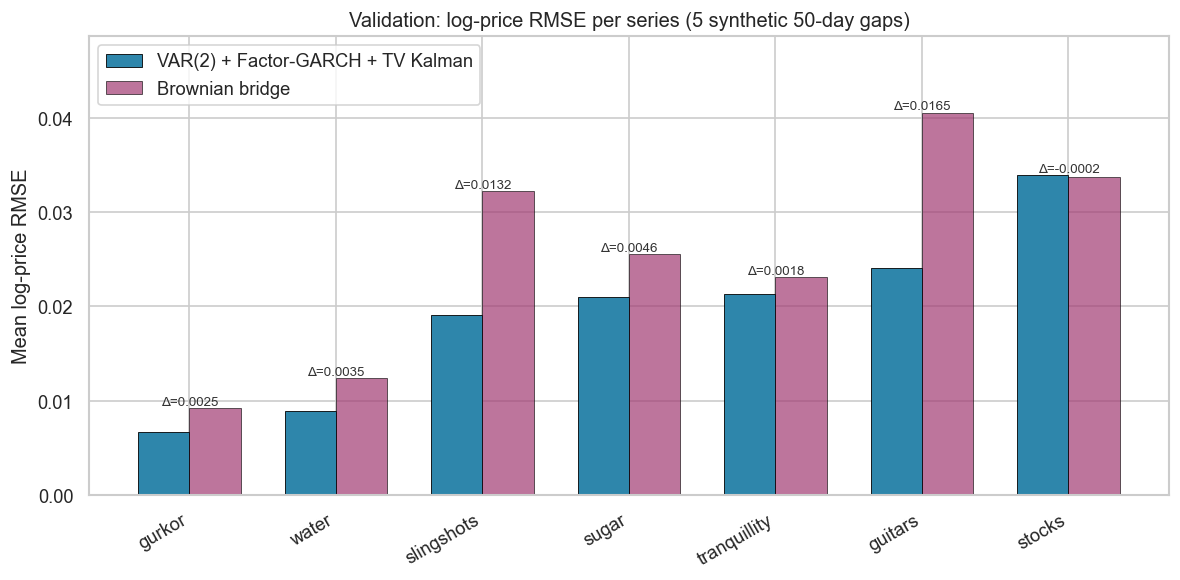

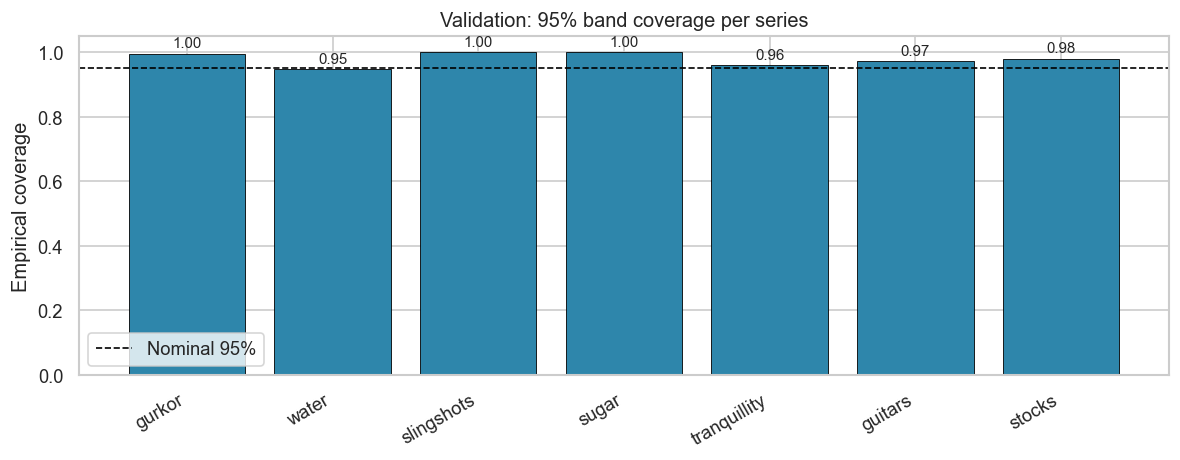

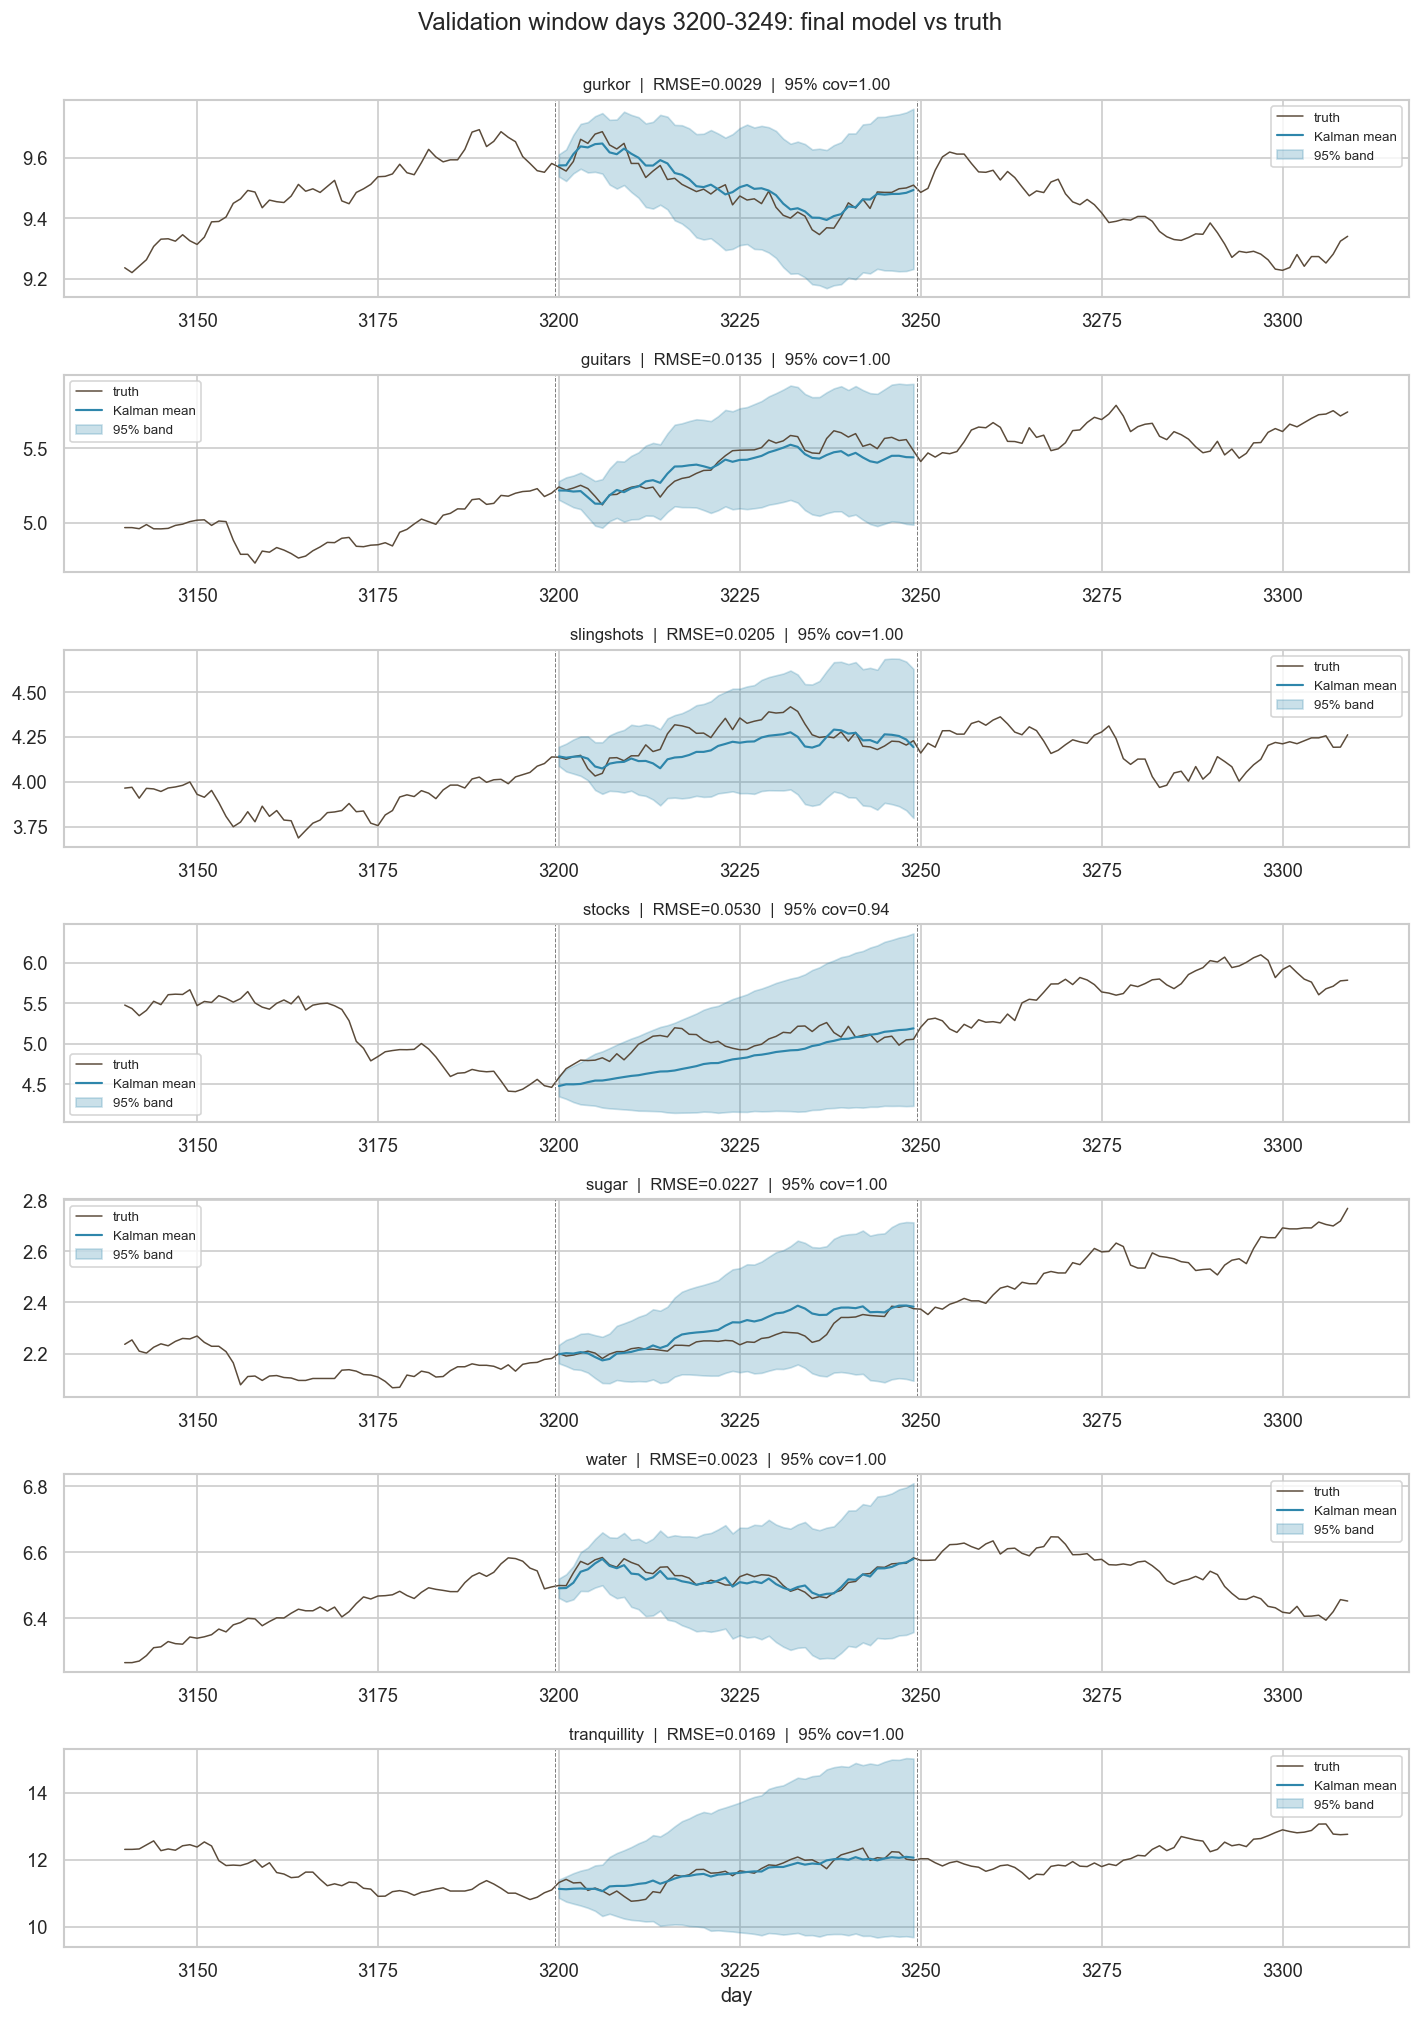

In [38]:
# ============================================================
# PLOTS: Final-model validation results
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(context='notebook', style='whitegrid')
plt.rcParams['figure.dpi'] = 120

# --- Figure 1: RMSE per series (Kalman vs Brownian bridge) ----------------

fig, ax = plt.subplots(figsize=(10, 5))

per_s = val_final.groupby('series')[['rmse_logP_kalman', 'rmse_logP_bridge']].mean().sort_values('rmse_logP_kalman')
x = np.arange(len(per_s))
width = 0.35

bars1 = ax.bar(x - width/2, per_s['rmse_logP_kalman'], width,
               label='VAR(2) + Factor-GARCH + TV Kalman', color='#2E86AB', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x + width/2, per_s['rmse_logP_bridge'], width,
               label='Brownian bridge', color='#A23B72', edgecolor='black', linewidth=0.5, alpha=0.7)

ax.set_ylabel('Mean log-price RMSE')
ax.set_title('Validation: log-price RMSE per series (5 synthetic 50-day gaps)')
ax.set_xticks(x)
ax.set_xticklabels(per_s.index, rotation=30, ha='right')
ax.legend(loc='upper left')
ax.set_ylim(0, per_s['rmse_logP_bridge'].max() * 1.2)

# annotate deltas
for i, (k, b) in enumerate(zip(per_s['rmse_logP_kalman'], per_s['rmse_logP_bridge'])):
    ax.annotate(f'Δ={b-k:.4f}', xy=(i, max(k, b)), ha='center', va='bottom', fontsize=8, color='#333333')

fig.tight_layout()
plt.show()

# --- Figure 2: 95% empirical coverage per series --------------------------

fig, ax = plt.subplots(figsize=(10, 4))

cov = val_final.groupby('series')['cov95_kalman'].mean().reindex(per_s.index)
colors = ['#2E86AB' if c >= 0.90 else '#F18F01' if c >= 0.80 else '#C73E1D' for c in cov]

bars = ax.bar(range(len(cov)), cov, color=colors, edgecolor='black', linewidth=0.5)
ax.axhline(0.95, color='black', linestyle='--', linewidth=1, label='Nominal 95%')
ax.set_ylabel('Empirical coverage')
ax.set_title('Validation: 95% band coverage per series')
ax.set_xticks(range(len(cov)))
ax.set_xticklabels(cov.index, rotation=30, ha='right')
ax.set_ylim(0, 1.05)
ax.legend()

for bar, c in zip(bars, cov):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{c:.2f}', ha='center', va='bottom', fontsize=9)

fig.tight_layout()
plt.show()

# --- Figure 3: Example interpolation paths for one validation window ------

# Pick the middle validation window for visualisation
gs_viz = mask_starts[len(mask_starts)//2]
ge_viz = gs_viz + GAP_LEN - 1
PAD = 60

fig, axes = plt.subplots(len(series_cols), 1, figsize=(12, 2.4 * len(series_cols)), sharex=False)

for ax, tgt in zip(axes, series_cols):
    # Re-run a single interpolation for this target (fast, uses pre-fit objects)
    ret_idx = np.arange(gs_viz, ge_viz + 2)
    train_idx = log_ret_common.index.difference(ret_idx)
    var_tr = VAR(log_ret_common.loc[train_idx]).fit(VAR_LAG)
    
    y_val = log_ret_common.copy()
    y_val.loc[ret_idx, tgt] = np.nan
    
    Su_seq = build_sigma_u_seq_val(
        y_val, tgt, ret_idx,
        non_stock_cols, Lambda_ns, N_VOL_FACTORS,
        stocks_intercept, stocks_coupling,
        log_h_mean, log_h_std, R_corr, cond_vol
    )
    
    sm_mean, sm_var = smooth_returns_tv(
        y_val, var_tr.coefs[0], var_tr.coefs[1], var_tr.intercept, Su_seq
    )
    imp = interpolate_gap(tgt, gs_viz, ge_viz, sm_mean, sm_var, df_common[tgt])
    
    # Context
    ctx = np.arange(max(df_common.index.min(), gs_viz - PAD),
                    min(df_common.index.max(), ge_viz + PAD) + 1)
    
    # Truth
    ax.plot(ctx, df_common.loc[ctx, tgt], color='#5B4B3A', lw=0.9, label='truth')
    
    # Imputed
    ax.plot(imp.index, imp['price_mean'], color='#2E86AB', lw=1.3, label='Kalman mean')
    ax.fill_between(imp.index, imp['price_lo95'], imp['price_hi95'],
                    color='#2E86AB', alpha=0.25, label='95% band')
    
    # Gap boundaries
    ax.axvline(gs_viz - 0.5, color='grey', ls='--', lw=0.6)
    ax.axvline(ge_viz + 0.5, color='grey', ls='--', lw=0.6)
    
    # Metrics in title
    truth_logP = np.log(df_common.loc[imp.index, tgt].values)
    rmse = np.sqrt(np.mean((imp['logP_mean'].values - truth_logP)**2))
    cov = np.mean((df_common.loc[imp.index, tgt].values >= imp['price_lo95'].values) &
                  (df_common.loc[imp.index, tgt].values <= imp['price_hi95'].values))
    ax.set_title(f'{tgt}  |  RMSE={rmse:.4f}  |  95% cov={cov:.2f}', fontsize=10)
    ax.legend(loc='best', fontsize=8)

axes[-1].set_xlabel('day')
fig.suptitle(f'Validation window days {gs_viz}-{ge_viz}: final model vs truth', y=1.00)
fig.tight_layout()
plt.show()

## 6. Apply to the real gaps

Run the smoother over `df_full` (all 5,256 days, all structural NaN gaps present). The filter uses VAR params from `df_common` (no leakage) and the disjoint-gap structure naturally lets it borrow strength from the six observed series on every missing day.

We also handle the five scattered 1-day `1000`-sentinel NaNs (days 36, 1194, 2836, 3430, 4118). These are single-day holes: the endpoint correction degenerates to *S = observed next-day log-return minus imputed $r_{t+1}$* but in practice the smoother handles them near-perfectly because all six other series are observed at those days.

In [39]:
# Build the return panel over df_full with NaNs where gaps sit
y_full = log_ret_full.copy()

# sm_mean_full, sm_var_full = smooth_returns(y_full, Phi1, Phi2, c_vec, Sigma_u) 
sm_mean_full, sm_var_full = smooth_returns_tv(y_full, Phi1, Phi2, c_vec, Sigma_u_seq) # i think this should be used

# ---- Volatility scaling inside each gap ----
# For each series, scale per-day Kalman variance by (GARCH vol / GARCH mean vol)^2.
# Where GARCH vol is unavailable (gap days), use the mean vol of the two calendar
# neighbours (before and after the gap) as a linear interpolant.
def scaled_variance(series, days, sm_var_full, cond_vol):
    base = sm_var_full.loc[days, series].values
    cv = cond_vol[series].dropna()
    mean_cv = cv.mean()
    # Linear interp of cv onto the gap days (log-scale for safety)
    day_arr = np.asarray(cv.index)
    log_cv = np.log(cv.values)
    interp = np.interp(days, day_arr, log_cv)
    cv_gap = np.exp(interp)
    scale = (cv_gap / mean_cv) ** 2
    return base * scale

# ---- Interpolate all structural gaps with vol-scaled variances ----
imputations = {}  # (series, gap_start) -> DataFrame
for c in series_cols:
    for gs, ge, ln in structural_gaps[c]:
        ret_idx = np.arange(gs, ge + 2)
        # vr_scaled = scaled_variance(c, ret_idx, sm_var_full, cond_vol) OBS ska vi ha full?
        # vr_scaled = scaled_variance(c, ret_idx, sm_var_full, cond_vol_full)
        #sm_var_mod = sm_var_full.copy()
        #sm_var_mod.loc[ret_idx, c] = vr_scaled

        # I think that i double scale if i uncomment the code above so instead:

        sm_var_mod = sm_var_full
        imp = interpolate_gap(c, gs, ge, sm_mean_full, sm_var_mod, df_full[c])
        imputations[(c, gs)] = imp

# ---- Fill in the 1000-sentinel days (single-day NaNs) ----
sentinel_days = [36, 1194, 2836, 3430, 4118]
df_filled = df_full.copy()
for c in series_cols:
    for d in sentinel_days:
        if pd.isna(df_filled.loc[d, c]):
            # logP_d = logP_{d-1} + r_d_hat  (smoother's imputed return at day d)
            r_hat = sm_mean_full.loc[d, c]
            # endpoint correction over the 2-return window [d, d+1]
            target = np.log(df_full.loc[d + 1, c]) - np.log(df_filled.loc[d - 1, c])
            mu_pair = np.array([r_hat, sm_mean_full.loc[d + 1, c]])
            vr_pair = np.array([sm_var_full.loc[d, c], sm_var_full.loc[d + 1, c]])
            mu_c, _ = apply_endpoint_constraint(mu_pair, vr_pair, target)
            df_filled.loc[d, c] = np.exp(np.log(df_filled.loc[d - 1, c]) + mu_c[0])

# ---- Fill in the 50-day gaps ----
for (c, gs), imp in imputations.items():
    df_filled.loc[imp.index, c] = imp['price_mean'].values

print(f'Remaining NaNs after interpolation: {int(df_filled.isna().sum().sum())}')
print(df_filled.isna().sum().to_string())

Remaining NaNs after interpolation: 0
gurkor          0
guitars         0
slingshots      0
stocks          0
sugar           0
water           0
tranquillity    0


## 7. Plots: imputed paths with uncertainty

Grid of all seven structural gaps with observed context ± 60 days on each side, the Kalman-smoother posterior mean, and the 95% pointwise price band.

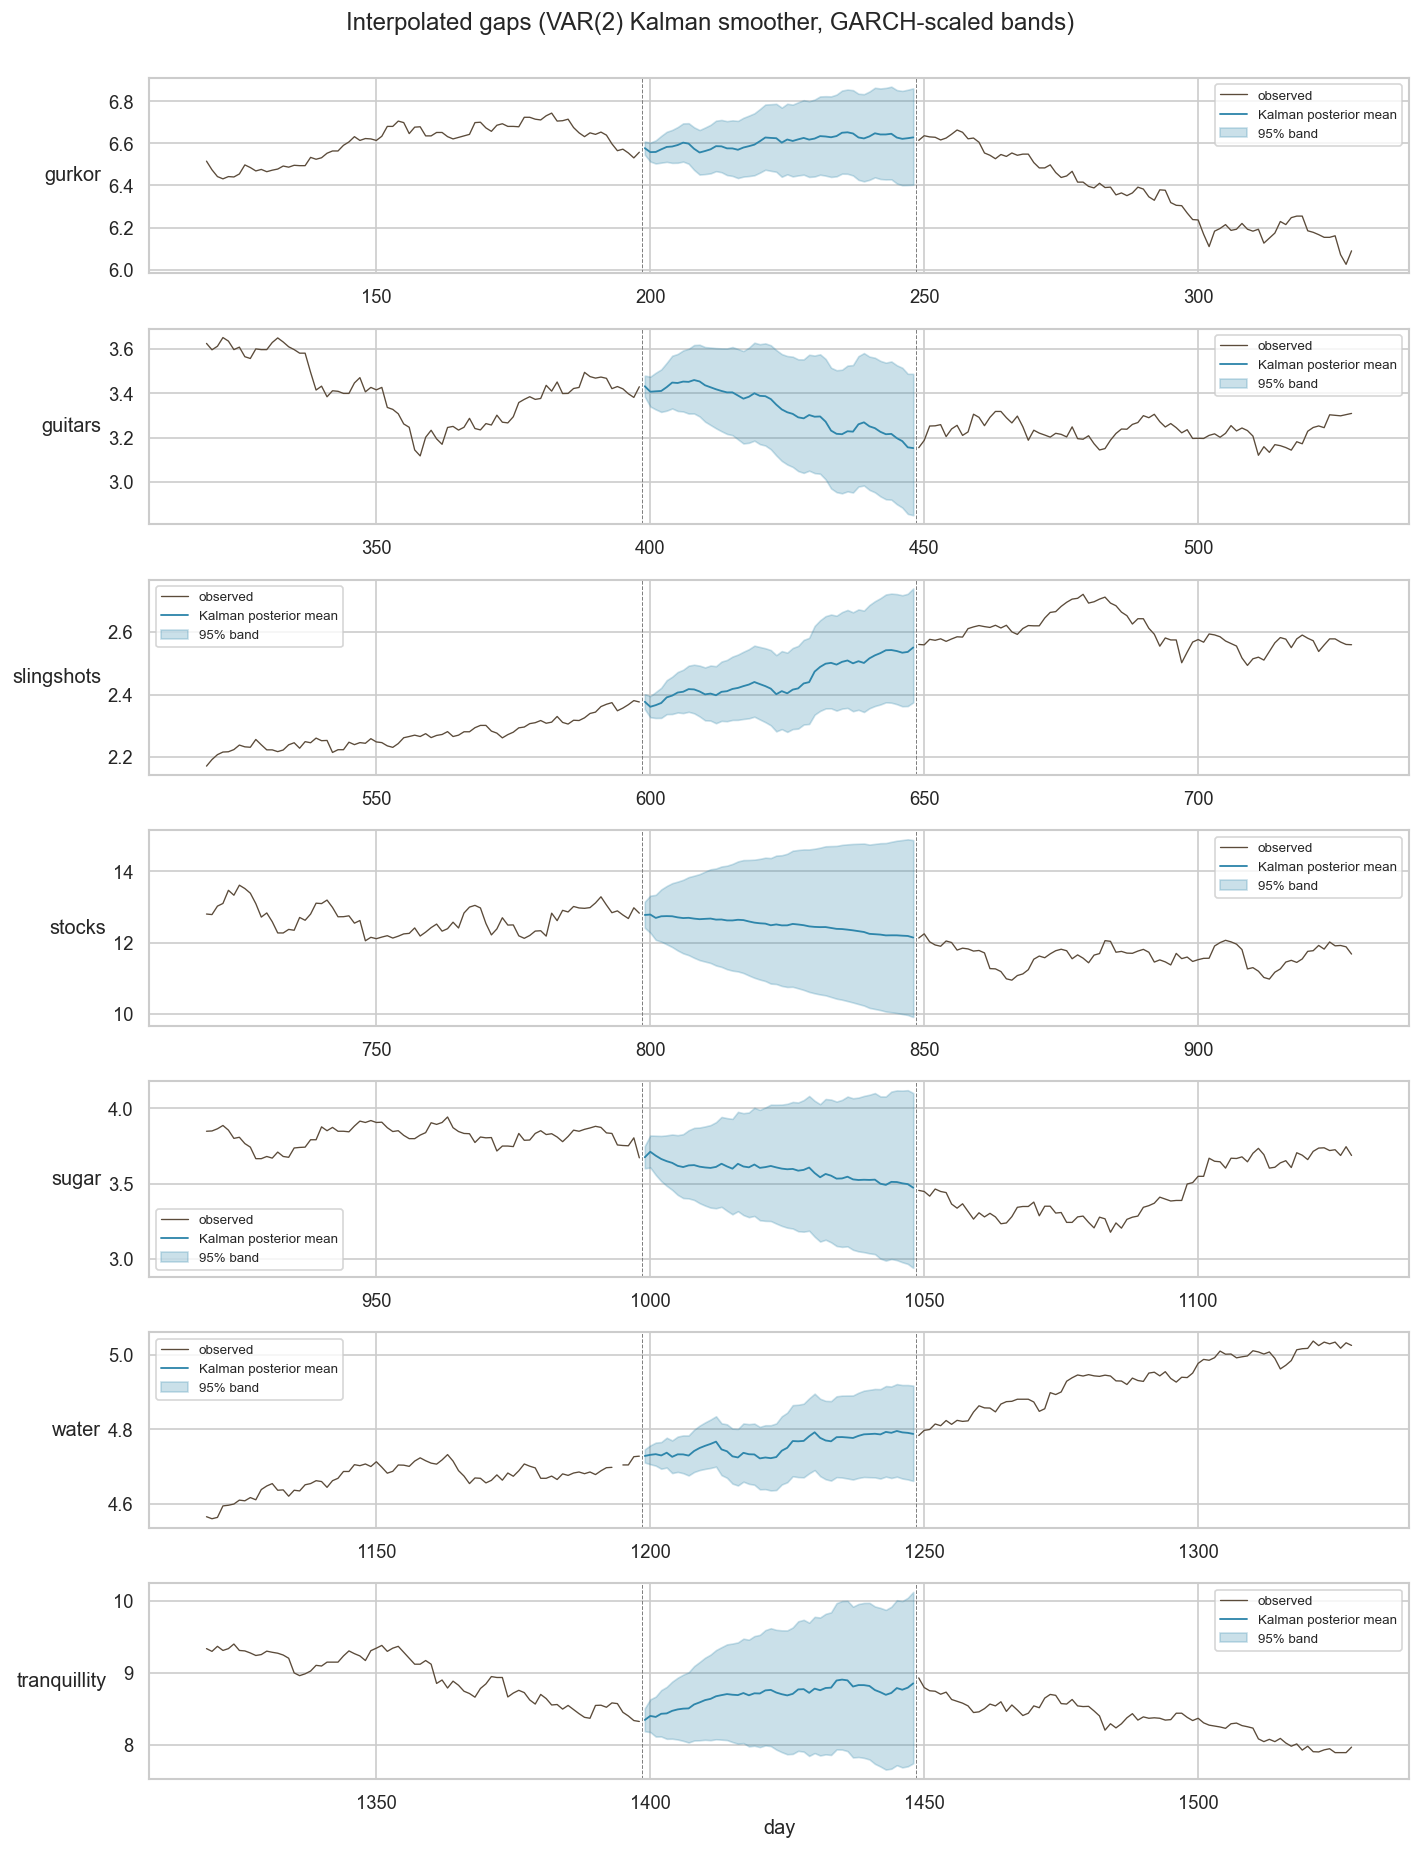

In [40]:
fig, axes = plt.subplots(len(series_cols), 1, figsize=(12, 2.2 * len(series_cols)))
PAD = 80
for ax, c in zip(axes, series_cols):
    gs, ge, ln = structural_gaps[c][0]  # each series has exactly one structural gap
    context = np.arange(max(1, gs - PAD), min(df_full.index.max(), ge + PAD) + 1)
    ax.plot(context, df_full.loc[context, c], color='#5B4B3A', lw=0.8,
            label='observed')
    imp = imputations[(c, gs)]
    ax.plot(imp.index, imp['price_mean'], color='#2E86AB', lw=1.1,
            label='Kalman posterior mean')
    ax.fill_between(imp.index, imp['price_lo95'], imp['price_hi95'],
                    color='#2E86AB', alpha=0.25, label='95% band')
    ax.axvline(gs - 0.5, color='grey', ls='--', lw=0.6)
    ax.axvline(ge + 0.5, color='grey', ls='--', lw=0.6)
    ax.set_ylabel(c, rotation=0, ha='right', va='center')
    ax.legend(loc='best', fontsize=8)
axes[-1].set_xlabel('day')
fig.suptitle('Interpolated gaps (VAR(2) Kalman smoother, GARCH-scaled bands)', y=1.00)
fig.tight_layout(); plt.show()

## 8. Notes / next steps

* **What drives accuracy.** The Kalman smoother wins over the Brownian-bridge baseline precisely because the six non-gap series are observed every day and carry information via both the contemporaneous residual covariance (`Sigma_u`) and the VAR lag coefficients. The endpoint correction pins the path to the correct cumulative drift.
* **Independence approximation.** The endpoint update assumes independent per-day variances inside the gap. A strictly correct version would build the full cross-time posterior covariance within the gap via the lag-1 smoother recursion and condition on $\mathbf 1^\top r = S$ jointly. Expected effect: slightly tighter bands in the middle of the gap, no material change at the ends.
* **Volatility hybrid.** VAR + univariate GARCH on residuals is a first-order fix. A full VAR-GARCH (DCC or BEKK) would jointly model time-varying covariance — relevant only if uncertainty-band calibration in the validation block is off.
* **Re-usable output.** `df_filled` is a fully-observed price panel — downstream notebooks (3, 4) can use it directly.